# Data Analysis and Visualization-Lab 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "Sample_Superstore_Cleaned.csv"
df = pd.read_csv(file_path, parse_dates=["Order Date", "Ship Date"])

df["Profitable"] = df["Profit"] > 0

print("Dataset shape:", df.shape)
print(df[["Order Date", "Region", "Category", "Sub-Category", "Discount", "Sales", "Profit"]].head())


Dataset shape: (9994, 22)
  Order Date Region         Category Sub-Category  Discount     Sales  \
0 2016-08-11  South        Furniture    Bookcases      0.00  261.9600   
1 2016-08-11  South        Furniture       Chairs      0.00  731.9400   
2 2016-12-06   West  Office Supplies       Labels      0.00   14.6200   
3 2015-11-10  South        Furniture       Tables      0.45  957.5775   
4 2015-11-10  South  Office Supplies      Storage      0.20   22.3680   

     Profit  
0   41.9136  
1  219.5820  
2    6.8714  
3 -383.0310  
4    2.5164  


## Task 1 

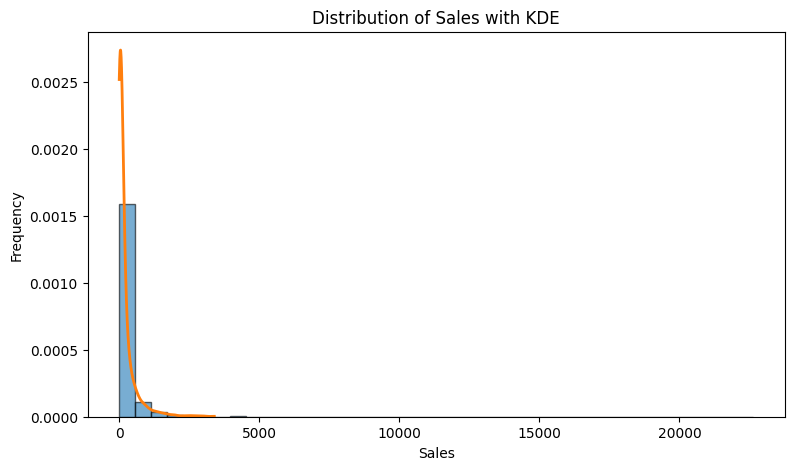

Skewness: 12.9728
Mean: 229.86
Median: 54.49


In [2]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(9, 5))
plt.hist(df["Sales"], bins=40, density=True, alpha=0.6, edgecolor="black")
x_grid = np.linspace(df["Sales"].min(), df["Sales"].quantile(0.995), 500)
kde = gaussian_kde(df["Sales"])
plt.plot(x_grid, kde(x_grid), linewidth=2)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales with KDE")
plt.show()

sales_skew = df["Sales"].skew()
sales_mean = df["Sales"].mean()
sales_median = df["Sales"].median()

print(f"Skewness: {sales_skew:.4f}")
print(f"Mean: {sales_mean:.2f}")
print(f"Median: {sales_median:.2f}")


**Conclusion:** The Sales distribution is strongly right-skewed, because its skewness is about 12.97 and the mean (229.86) is much higher than the median (54.49). Therefore, the mean is pulled upward by very large orders, so the median is often a more representative summary of a typical order.

## Task 2 


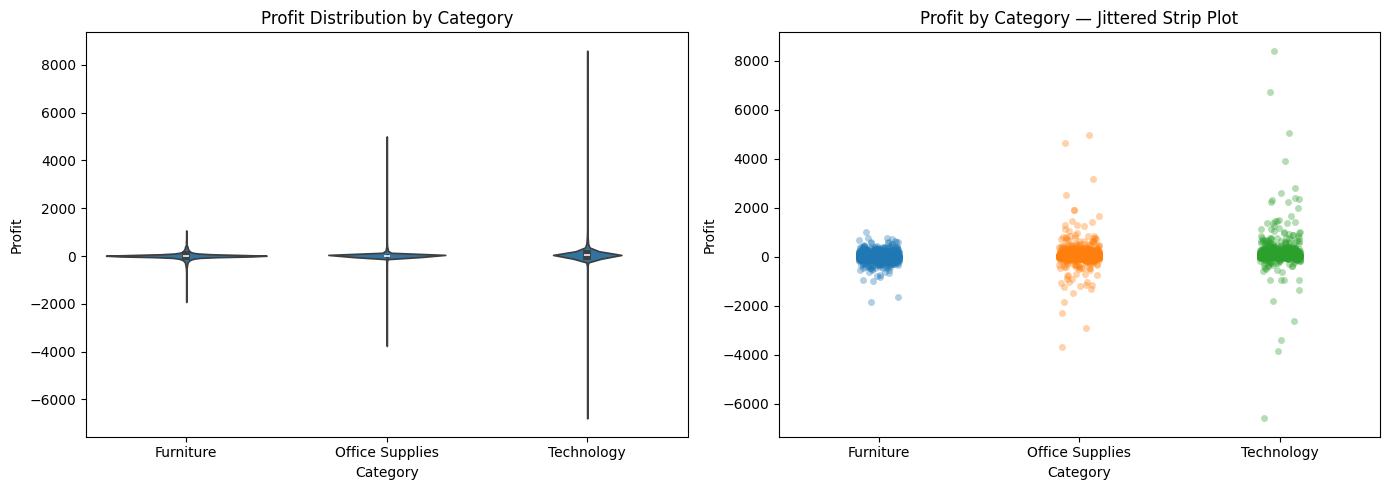

                      mean   median         std        min       max  count
Category                                                                   
Furniture         8.699327   7.7748  136.049246 -1862.3124  1013.127   2121
Office Supplies  20.327050   6.8824  164.887280 -3701.8928  4946.370   6026
Technology       78.752002  25.0182  428.816633 -6599.9780  8399.976   1847


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x="Category", y="Profit", ax=axes[0])
axes[0].set_title("Profit Distribution by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Profit")

sns.stripplot(data=df, x="Category", y="Profit", jitter=True, alpha=0.35, ax=axes[1])
axes[1].set_title("Profit by Category — Jittered Strip Plot")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Profit")

plt.tight_layout()
plt.show()

print(df.groupby("Category")["Profit"].agg(["mean", "median", "std", "min", "max", "count"]))


**Conclusion:** The violin plot better reveals a bimodal or unusually spread-out distribution because it shows the estimated density and overall shape. In this dataset, Technology has the widest profit spread (standard deviation = 428.82), while the strip plot is especially useful for seeing the individual observations and actual sample density.

## Task 3 

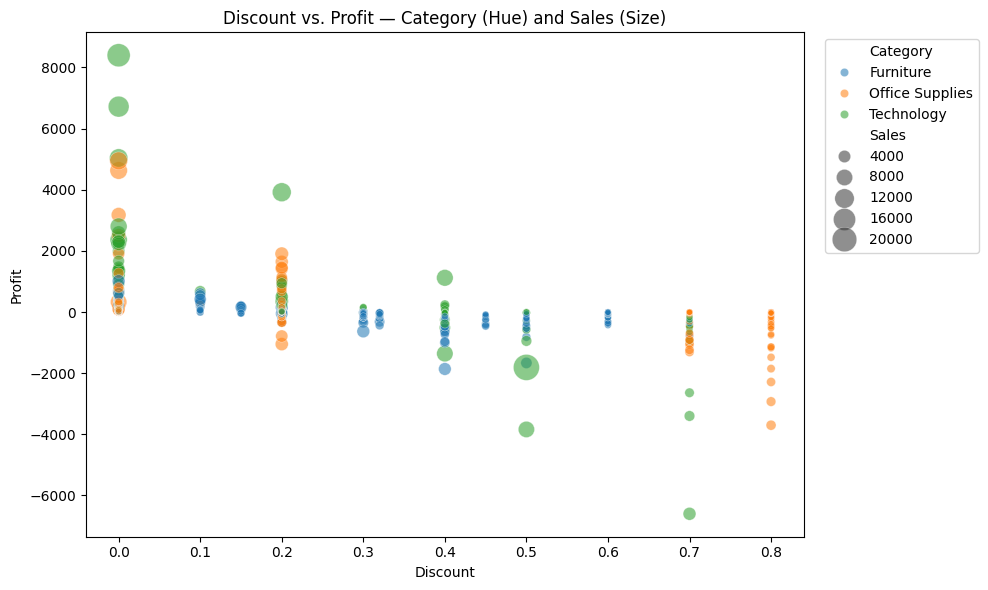

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    size="Sales",
    sizes=(20, 350),
    alpha=0.55
)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs. Profit — Category (Hue) and Sales (Size)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Conclusion:** The four-variable encoding makes it possible to see that large-sales orders are not automatically high-profit orders. Large bubbles appear among both positive-profit and loss-making observations, while category membership helps show how this pattern is distributed across product groups.

## Task 4 

Pearson correlation matrix:


,Sales,Quantity,Discount,Profit
Sales,1.0000,0.2008,-0.0282,0.4791
Quantity,0.2008,1.0000,0.0086,0.0663
Discount,-0.0282,0.0086,1.0000,-0.2195
Profit,0.4791,0.0663,-0.2195,1.0000



Spearman correlation matrix:


,Sales,Quantity,Discount,Profit
Sales,1.0000,0.3274,-0.0570,0.5184
Quantity,0.3274,1.0000,-0.0009,0.2345
Discount,-0.0570,-0.0009,1.0000,-0.5434
Profit,0.5184,0.2345,-0.5434,1.0000


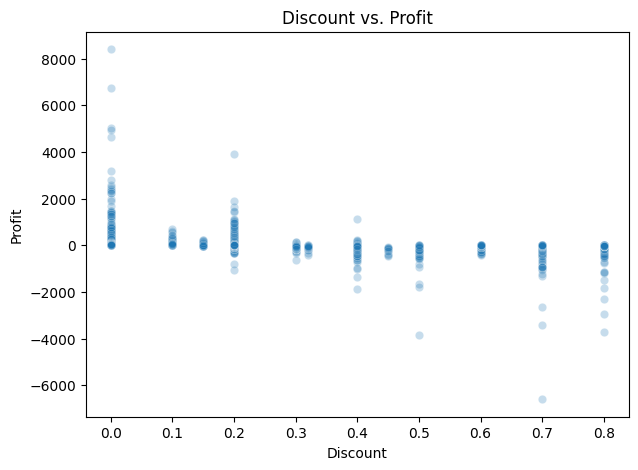

Pearson Discount–Profit: -0.2195
Spearman Discount–Profit: -0.5434


In [5]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

pearson = df[numeric_cols].corr(method="pearson")
spearman = df[numeric_cols].corr(method="spearman")

print("Pearson correlation matrix:")
display(pearson.round(4))

print("\nSpearman correlation matrix:")
display(spearman.round(4))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.25)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs. Profit")
plt.show()

print(f"Pearson Discount–Profit: {pearson.loc['Discount', 'Profit']:.4f}")
print(f"Spearman Discount–Profit: {spearman.loc['Discount', 'Profit']:.4f}")


**Conclusion:** The most noticeable disagreement is between Discount and Profit: Pearson is about −0.2195, while Spearman is about −0.5434. The scatter plot shows a non-uniform, non-linear pattern with extreme observations, so Pearson's linear measure is much weaker than the rank-based Spearman result.

**Correlation is not causation:** even when two variables move together, the relationship may be explained by other variables, reverse relationships, or coincidence. A correlation coefficient alone does not establish that one variable causes the other.

## Task 5 

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.16,167026.42,170416.31,501239.89
East,208291.20,205516.06,264973.98,678781.24
South,117298.68,125651.31,148771.91,391721.90
West,252612.74,220853.25,251991.83,725457.82
All,741999.80,719047.03,836154.03,2297200.86


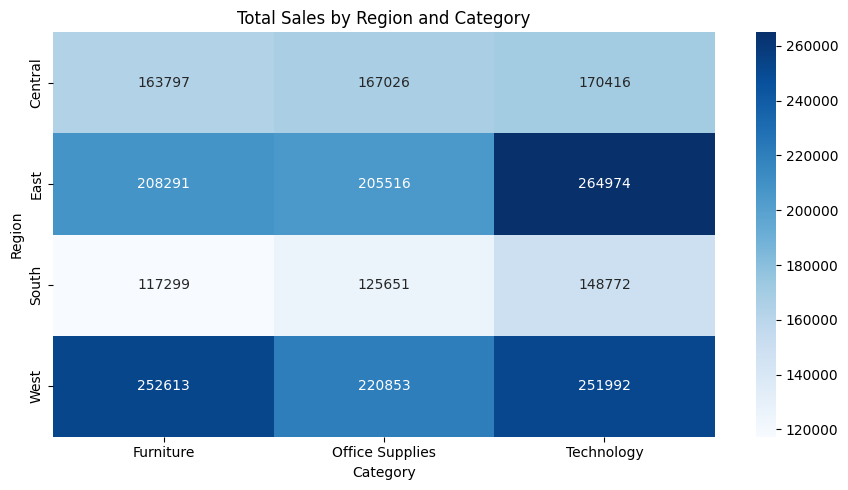

Highest region-category combination: East × Technology
Total sales: 264,973.98


In [6]:
sales_pivot = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    margins=True
)

display(sales_pivot.round(2))

plt.figure(figsize=(9, 5))
sns.heatmap(
    sales_pivot.iloc[:-1, :-1],
    annot=True,
    fmt=".0f",
    cmap="Blues"
)
plt.title("Total Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

region_category = sales_pivot.iloc[:-1, :-1].stack()
best_region, best_category = region_category.idxmax()
best_sales = region_category.max()

print(f"Highest region-category combination: {best_region} × {best_category}")
print(f"Total sales: {best_sales:,.2f}")


**Conclusion:** The East × Technology combination contributes the most sales, with approximately 264,973.98 in total sales. The margins=True totals provide a useful sanity check for the regional, category, and overall sales totals.

## Task 6 

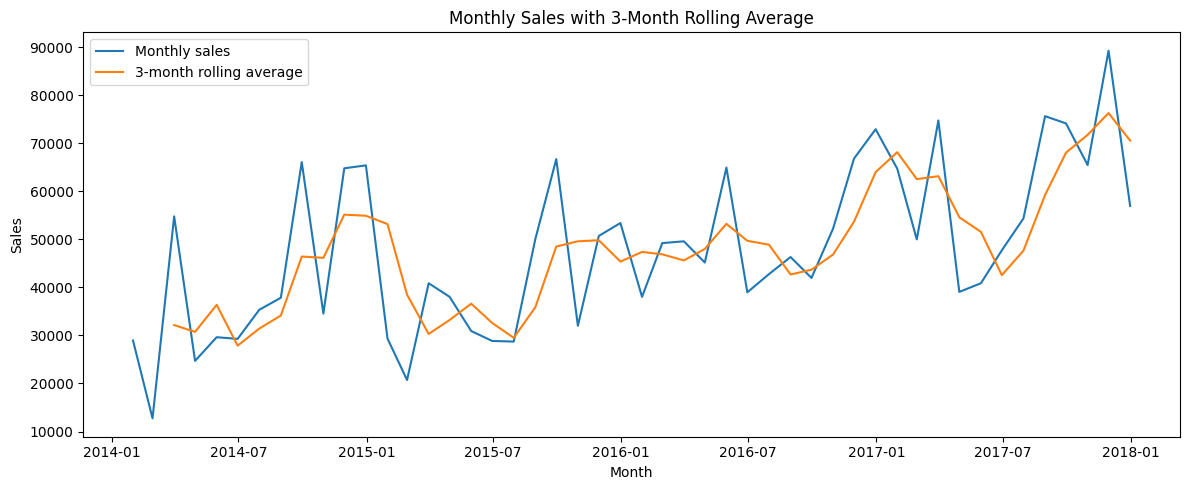

In [7]:
ts = df.set_index("Order Date")["Sales"].sort_index()

monthly_sales = ts.resample("ME").sum()
rolling_3m = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, label="Monthly sales")
plt.plot(rolling_3m.index, rolling_3m.values, label="3-month rolling average")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales with 3-Month Rolling Average")
plt.legend()
plt.tight_layout()
plt.show()


**Conclusion:** The raw monthly line shows short-term ups and downs that can make the underlying movement difficult to read. The 3-month rolling average smooths this month-to-month noise, making the broader sales trend easier to identify.

## Task 7

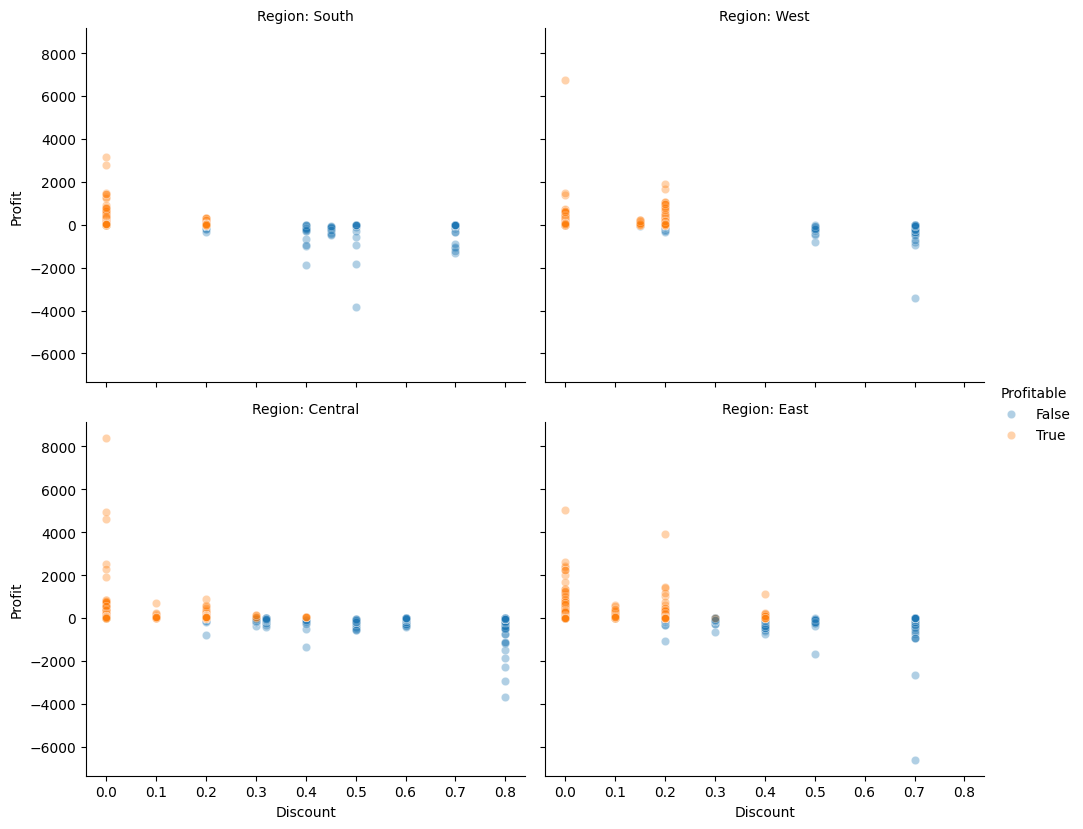

Discount–Profit Pearson correlation by region:


Region           
Central  Discount   -0.225365
East     Discount   -0.225752
South    Discount   -0.272111
West     Discount   -0.154970
Name: correlation, dtype: float64

In [8]:
g = sns.FacetGrid(
    df,
    col="Region",
    hue="Profitable",
    col_wrap=2,
    height=4.2,
    aspect=1.2
)
g.map_dataframe(
    sns.scatterplot,
    x="Discount",
    y="Profit",
    alpha=0.35
)
g.add_legend(title="Profitable")
g.set_axis_labels("Discount", "Profit")
g.set_titles("Region: {col_name}")
plt.show()

print("Discount–Profit Pearson correlation by region:")
display(df.groupby("Region")[["Discount", "Profit"]].corr().iloc[0::2, -1].rename("correlation"))


**Conclusion:** The South region shows a visibly stronger negative discount–profit relationship than several other regions (regional Pearson correlation = −0.272), whereas West is weaker (= −0.155). The facets make this regional difference easier to compare without crowding all observations into one plot.

## Task 8 

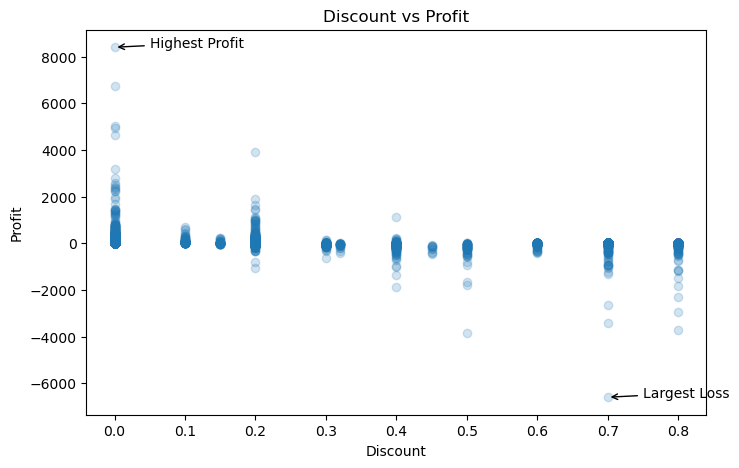

In [4]:
best = df.loc[df["Profit"].idxmax()]
worst = df.loc[df["Profit"].idxmin()]

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.2
)

plt.annotate(
    "Highest Profit",
    xy=(best["Discount"], best["Profit"]),
    xytext=(best["Discount"] + 0.05, best["Profit"]),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "Largest Loss",
    xy=(worst["Discount"], worst["Profit"]),
    xytext=(worst["Discount"] + 0.05, worst["Profit"]),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")

plt.show()